In [1]:
import time
import h5py


import numpy as np
import matplotlib.pyplot as plt
import sys
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
%matplotlib widget 

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
#run = 104 #XAS step mono
#run = 119 #waveplate
run = 76 #XAS fly mono
run = 151 #fixed energy
bg = 64

exp = 'rix100836924'
#79,81,82,83,85,94,95,96,98



fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
bgname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{bg:04d}.h5'
#fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fyaml = '../roi_input.yml'
# with h5py.File(fname, 'r') as fh:
#     data = SmallData(fh,fyaml)
#     with h5py.File(bgname, 'r') as fhbg:
#         red =Reduced(fh,fhbg,fyaml,clear_memory=False)

#with SmallData(fname,fyaml) as data:
# with Reduced(fname,bgname,fyaml) as red:
#     red.data.integrating.axis_svls.full_area

red = Reduced(fname,bgname,fyaml,scantype='mono_fly')

accessing intgrp
initialising <HDF5 group "/intg/andor_vls" (88 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (92 members)>
setting up properties
accessing intgrp
initialising <HDF5 group "/intg/andor_vls" (140 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (144 members)>
setting up properties
<KeysViewHDF5 ['Sums', 'UserDataCfg', 'c_piranha', 'crix_w8', 'det_crix_w8', 'det_rix_fim0', 'det_rix_fim1', 'epics_archiver', 'gmd', 'intg', 'lightStatus', 'mono_hrencoder', 'pcav', 'rix_fim0', 'rix_fim1', 'timestamp', 'timing', 'xgmd']>
runtype unknown


/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/process.py:245: RuntimeWarning: Mean of empty slice
  tmp_on = np.nanmean(self.proc[detector]['on'],axis=0)
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/process.py:246: RuntimeWarning: Mean of empty slice
  tmp_off = np.nanmean(self.proc[detector]['off'],axis=0)


In [8]:
np.sum(red.andor_vls_off)


0.13442080223630623

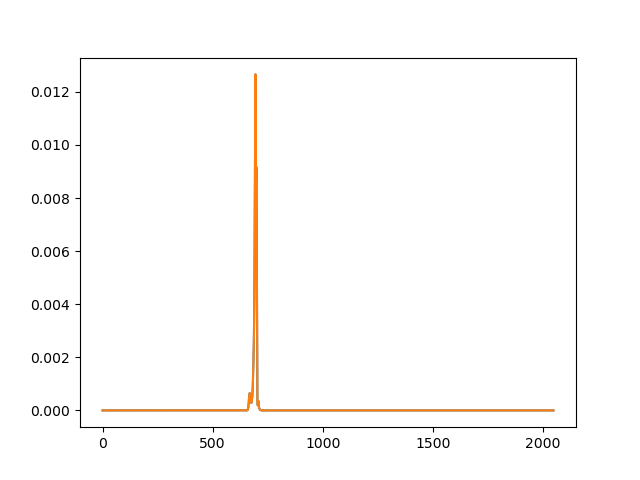

In [9]:
fig,ax=plt.subplots(1,1)
ax.plot(red.andor_vls_off)
ax.plot(red.andor_vls_off)

In [4]:
cal=[-9.86289253e-04,  1.01299833e+03]
hrencoder = red.data.integrating.andor_vls.mono_encoder

np.polyval(cal,hrencoder)

array([29798.4103911 , 29798.79405762, 29722.35861309, ...,
       29712.6209793 , 29711.81715356, 29712.50361088])

In [5]:
sm = SmallData(fname,fyaml)

In [5]:
dat = h5py.File(fname, 'r')
dat['intg']['axis_svls'].keys()

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'full_area', 'lightStatus_sum_laser', 'lightStatus_sum_xray', 'mono_hrencoder_sum

In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [5]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1.keys()


<KeysViewHDF5 ['Sums', 'UserDataCfg', 'c_piranha', 'crix_w8', 'det_crix_w8', 'det_rix_fim0', 'det_rix_fim1', 'epics_archiver', 'gmd', 'intg', 'lightStatus', 'mono_hrencoder', 'pcav', 'rix_fim0', 'rix_fim1', 'scan', 'timestamp', 'timing', 'xgmd']>

In [6]:
test1['intg']['andor_vls']['mono_hrencoder_sum_value'][:100]

array([-14194474, -29535113, -29535665, -29447433, -29536196, -29535504,
       -29535159, -29535014, -29446873, -29448026, -29447973, -29446607,
       -29447601, -29447486, -29446974, -29447329, -29446424, -29447861,
       -29448010, -29447354, -29447036, -29447127, -29447591, -29447163,
       -29447062, -29447091, -29446757, -29447545, -29446650, -29446361,
       -29446922, -29447157, -29447401, -29446957, -29446735, -29447114,
       -29446936, -29447935, -29447125, -29447684, -29446905, -29446834,
       -29446168, -29447333, -29447788, -29447075, -29446891, -29447406,
       -29447832, -29447598, -29447141, -29447373, -29447499, -29446358,
       -29447138, -29447269, -29447400, -29447228, -29447163, -29447657,
       -29446979, -29447091, -29447296, -29447568, -29447670, -29446496,
       -29447872, -29447579, -29447142, -29446888, -29446670, -29447847,
       -29447601, -29446681, -29447700, -29447022, -34913153, -29446986,
       -29446788, -29447617, -29447881, -29446191, 